# Does Indonesia's AI Adoption Track US-Measured Exposure?

## Research question

Does Indonesia's occupation-level Claude usage correspond to the AI exposure hierarchy measured in the US labor market?

## Thesis

We find no statistical relationship. Indonesia's AI adoption follows a distinct trajectory shaped by domestic educational, institutional, and cultural priorities rather than the US exposure ordering.

## Approach

1. Compute Indonesia's Revealed Comparative Advantage (RCA) per occupation using AEI geographic data
2. Pair each occupation with Massenkoff & McCrory (2026) US observed exposure
3. Test the rank correlation using Spearman's $\rho$ (two-sided test for independence)
4. Decompose the result into four quadrants (HH / HL / LH / LL) to interpret the geometry of the null

## Why Spearman

Observed exposure is heavily right-skewed with a 54% zero mass and fails Shapiro-Wilk normality at $p < 10^{-36}$. RCA is a ratio bounded below by zero, structurally non-normal. Bivariate normality fails; Pearson is not appropriate. Spearman operates on ranks and is robust to these distributional properties (Hollander, Wolfe & Chicken 2014, procedure 8.70).

## References

1. Acemoglu, D. (2024). *The Simple Macroeconomics of AI*. NBER WP 32487.
2. Appel, R., McCrory, P., Tamkin, A., Stern, M., McCain, M. & Neylon, T. (2025). Anthropic Economic Index Report: Uneven Geographic and Enterprise AI Adoption.
3. Balassa, B. (1965). Trade Liberalisation and 'Revealed' Comparative Advantage. *The Manchester School*, 33(2), 99–123.
4. Hollander, M., Wolfe, D.A. & Chicken, E. (2014). *Nonparametric Statistical Methods*, 3rd ed. Wiley.
5. Laursen, K. (2015). Revealed Comparative Advantage and the Alternatives. *Eurasian Business Review*, 5, 99–115.
6. Massenkoff, M. & McCrory, P. (2026). Labor Market Impacts of AI. Anthropic Research.

## 1. Setup and data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, shapiro
from pathlib import Path
from huggingface_hub import hf_hub_download
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

REPO_ID = 'Anthropic/EconomicIndex'
RELEASE = 'release_2025_09_15'
AEI_DIR = Path('./aei_data')
OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

INDONESIA = 'ID'

SOC_MAJOR_LABELS = {
    '11': 'Management', '13': 'Business & Financial', '15': 'Computer & Mathematical',
    '17': 'Architecture & Engineering', '19': 'Life, Physical & Social Science',
    '21': 'Community & Social Service', '23': 'Legal', '25': 'Educational Instruction',
    '27': 'Arts, Design, Entertainment', '29': 'Healthcare Practitioners',
    '31': 'Healthcare Support', '33': 'Protective Service', '35': 'Food Preparation',
    '37': 'Building & Grounds Cleaning', '39': 'Personal Care & Service', '41': 'Sales',
    '43': 'Office & Admin Support', '45': 'Farming, Fishing, Forestry',
    '47': 'Construction & Extraction', '49': 'Installation, Maintenance, Repair',
    '51': 'Production', '53': 'Transportation & Material Moving',
}

print('Setup complete.')

Setup complete.


In [3]:
# Pull the AEI data needed
for f in [
    f'{RELEASE}/data/intermediate/aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv',
    f'{RELEASE}/data/intermediate/onet_task_statements.csv',
]:
    try:
        hf_hub_download(repo_id=REPO_ID, filename=f, repo_type='dataset', local_dir=AEI_DIR)
    except Exception as e:
        print(f'Could not fetch {f}: {e}')

geo = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv')
onet_tasks = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/onet_task_statements.csv')
job_exposure = pd.read_csv('job_exposure.csv')

# Filter out unclassified rows at both country and cluster levels
n_before = len(geo)
geo = geo[geo.geo_id != 'not_classified']
geo = geo[geo.cluster_name.fillna('').str.lower() != 'not_classified']
print(f'Filtered {n_before - len(geo):,} not_classified rows, {len(geo):,} remain.')
print(f'job_exposure: {job_exposure.shape} — US occupations with observed exposure')

Filtered 1,406 not_classified rows, 98,656 remain.
job_exposure: (756, 3) — US occupations with observed exposure


## 2. Compute Indonesia's occupation-level RCA

For each occupation $k$:

$$RCA_{\text{Indonesia}, k} = \frac{\text{Indonesia's share of its Claude usage in occupation } k}{\text{Global share of Claude usage in occupation } k}$$

In [4]:
# Find the percentage variable for task facet
task_pct_var = next(v for v in geo[geo.facet == 'onet_task'].variable.unique() if 'pct' in v.lower())

task_usage = (
    geo[(geo.facet == 'onet_task') & (geo.variable == task_pct_var)]
    [['geo_id', 'cluster_name', 'value']]
    .rename(columns={'value': 'usage_pct', 'cluster_name': 'task'})
)

# Map tasks to SOC occupation codes via O*NET task statements
normalize = lambda s: str(s).strip().lower().rstrip('.')
task_col = next((c for c in onet_tasks.columns if 'task' in c.lower() and onet_tasks[c].dtype == 'object'), None)
soc_col = next((c for c in onet_tasks.columns if 'onet' in c.lower() or 'soc' in c.lower()), None)
onet_tasks['task_norm'] = onet_tasks[task_col].apply(normalize)
onet_tasks['occ_code'] = onet_tasks[soc_col].astype(str).str.split('.').str[0]
onet_tasks['soc_major'] = onet_tasks[soc_col].astype(str).str[:2]
task_to_occ = onet_tasks[['task_norm', 'occ_code', 'soc_major']].drop_duplicates('task_norm')

task_usage['task_norm'] = task_usage.task.apply(normalize)
task_usage = task_usage.merge(task_to_occ, on='task_norm', how='left')
print(f'Task-to-SOC match rate: {task_usage.occ_code.notna().mean():.0%}')

# Aggregate task usage to occupation level per country, then renormalize to shares
occ_by_country = (
    task_usage.dropna(subset=['occ_code'])
    .groupby(['geo_id', 'occ_code'])['usage_pct'].sum().reset_index()
)
totals = occ_by_country.groupby('geo_id').usage_pct.sum().rename('total')
occ_by_country = occ_by_country.merge(totals, on='geo_id')
occ_by_country['share_pct'] = 100 * occ_by_country.usage_pct / occ_by_country.total

# Indonesia's shares
id_occ = occ_by_country[occ_by_country.geo_id == INDONESIA][['occ_code', 'share_pct']].rename(
    columns={'share_pct': 'indonesia_share'}
)

# Global median share and country count per occupation
global_stats = (
    occ_by_country.groupby('occ_code')
    .agg(global_median=('share_pct', 'median'),
         n_countries=('geo_id', 'nunique'))
    .reset_index()
)

# Build analysis dataset: US exposure + Indonesia share + global median + RCA
df = (
    job_exposure
    .merge(id_occ, on='occ_code', how='left')
    .merge(global_stats, on='occ_code', how='left')
)
df['indonesia_share'] = df.indonesia_share.fillna(0)
df['RCA'] = df.indonesia_share / df.global_median.replace(0, np.nan)

print(f'\nTotal US occupations with exposure data:  {len(job_exposure)}')
print(f'With RCA defined (global median > 0):     {df.RCA.notna().sum()}')

Task-to-SOC match rate: 99%

Total US occupations with exposure data:  756
With RCA defined (global median > 0):     459


## 3. Analysis sample

We restrict to occupations that (a) have positive US exposure, (b) have defined RCA, and (c) have a reliable global baseline ($\geq 5$ countries with usage).

In [5]:
both = df.dropna(subset=['RCA']).copy()
both = both[both.observed_exposure > 0]
both = both[both.n_countries >= 5]

both['soc_major'] = both.occ_code.str[:2]
both['soc_label'] = both.soc_major.map(SOC_MAJOR_LABELS).fillna(both.soc_major)

print(f'Analysis sample: n = {len(both)} occupations')
print(f'  All have positive US exposure (range: {both.observed_exposure.min():.3f} to {both.observed_exposure.max():.3f})')
print(f'  Indonesia zero-adoption: {(both.RCA == 0).sum()} ({(both.RCA == 0).mean():.0%})')
print(f'  Indonesia positive-adoption: {(both.RCA > 0).sum()} ({(both.RCA > 0).mean():.0%})')

Analysis sample: n = 142 occupations
  All have positive US exposure (range: 0.012 to 0.648)
  Indonesia zero-adoption: 79 (56%)
  Indonesia positive-adoption: 63 (44%)


## 4. Distributional diagnostic

Why not Pearson? Because neither margin is normal.

In [7]:
from scipy.stats import skew, kurtosis

def describe(x, name):
    W, p = shapiro(x)
    return {
        'variable': name,
        'n': len(x),
        'mean_val': x.mean(),        # renamed to avoid collision
        'median_val': np.median(x),  # renamed to avoid collision
        'skewness': skew(x),
        'excess_kurtosis': kurtosis(x),
        'shapiro_W': W,
        'shapiro_p': p,
        'reject_normal': p < 0.05,
    }

diag = pd.DataFrame([
    describe(both.observed_exposure.values, 'US observed exposure'),
    describe(both.RCA.values, 'Indonesia RCA'),
])

print('=== DISTRIBUTIONAL DIAGNOSTIC ===\n')
for _, r in diag.iterrows():
    print(f'{r.variable}:')
    print(f'  n = {r.n}, mean = {r.mean_val:.4f}, median = {r.median_val:.4f}')
    print(f'  skewness = {r.skewness:+.3f}  (symmetric if near 0)')
    print(f'  excess kurtosis = {r.excess_kurtosis:+.3f}  (normal tails if near 0)')
    print(f'  Shapiro-Wilk W = {r.shapiro_W:.4f}, p = {r.shapiro_p:.2e}')
    verdict = 'REJECT normality' if r.reject_normal else 'Cannot reject normality'
    print(f'  -> {verdict} at alpha = 0.05\n')

diag.to_csv(OUTPUT_DIR / 'distributional_diagnostic.csv', index=False)

=== DISTRIBUTIONAL DIAGNOSTIC ===

US observed exposure:
  n = 142, mean = 0.2028, median = 0.1625
  skewness = +0.767  (symmetric if near 0)
  excess kurtosis = -0.234  (normal tails if near 0)
  Shapiro-Wilk W = 0.9132, p = 1.53e-07
  -> REJECT normality at alpha = 0.05

Indonesia RCA:
  n = 142, mean = 0.4733, median = 0.0000
  skewness = +2.053  (symmetric if near 0)
  excess kurtosis = +4.366  (normal tails if near 0)
  Shapiro-Wilk W = 0.6896, p = 6.12e-16
  -> REJECT normality at alpha = 0.05



## 5. The headline test: Spearman rank correlation

**Hypotheses** (Hollander, Wolfe & Chicken 2014, procedure 8.70):
- $H_0$: Indonesia's RCA and US observed exposure are independent
- $H_1$: Indonesia's RCA and US observed exposure are not independent (two-sided)

Reject $H_0$ if $|r_s| \geq r_{s, \alpha/2}$.

In [8]:
x = both.observed_exposure.values
y = both.RCA.values
result = spearmanr(x, y)
rho = float(result.statistic)
p_value = float(result.pvalue)
n = len(both)

# Critical value at alpha = 0.05 from large-sample approximation
alpha = 0.05
z_critical = 1.96  # two-sided
rs_critical = z_critical / np.sqrt(n - 1)

print('=== HEADLINE RESULT ===\n')
print(f'  Spearman rho:        {rho:+.4f}')
print(f'  p-value (two-sided): {p_value:.4f}')
print(f'  Sample size:         n = {n}')
print(f'  Critical |rho| at alpha=0.05: {rs_critical:.3f}')
print(f'  |rho| observed:      {abs(rho):.3f}')
print()
if p_value < 0.05:
    print(f'  Decision: REJECT H0 at alpha = 0.05')
    print(f'  -> Indonesia RCA and US exposure are NOT independent')
else:
    print(f'  Decision: FAIL TO REJECT H0 at alpha = 0.05')
    print(f'  -> No statistical evidence of a relationship')
    print(f'  -> Indonesia RCA and US exposure are consistent with independence')

=== HEADLINE RESULT ===

  Spearman rho:        -0.0013
  p-value (two-sided): 0.9879
  Sample size:         n = 142
  Critical |rho| at alpha=0.05: 0.165
  |rho| observed:      0.001

  Decision: FAIL TO REJECT H0 at alpha = 0.05
  -> No statistical evidence of a relationship
  -> Indonesia RCA and US exposure are consistent with independence


## 6. Why the null? Four-quadrant decomposition

A null Spearman arises when Indonesia's over-specializations and under-specializations offset each other along the exposure dimension. The quadrants make this visible.

In [9]:
# Quadrant boundaries: exposure at median, RCA at 1 (proportional to global)
exp_median = both.observed_exposure.median()

def assign_quadrant(row):
    hi_exp = row.observed_exposure >= exp_median
    hi_rca = row.RCA >= 1
    return ('HH' if hi_exp and hi_rca
            else 'HL' if hi_exp and not hi_rca
            else 'LH' if hi_rca
            else 'LL')

both['quadrant'] = both.apply(assign_quadrant, axis=1)

quadrant_info = {
    'HH': 'High US exposure + High Indonesia RCA — observable adjustment cohort',
    'HL': 'High US exposure + Low Indonesia RCA — latent adoption gap',
    'LH': 'Low US exposure + High Indonesia RCA — distinctive Indonesian specialization',
    'LL': 'Low US exposure + Low Indonesia RCA — outside AI footprint for both countries',
}

quadrant_counts = both.quadrant.value_counts()
print('=== QUADRANT SIZES ===\n')
for q in ['HH', 'HL', 'LH', 'LL']:
    count = quadrant_counts.get(q, 0)
    pct = 100 * count / len(both)
    print(f'  {q}: n = {count:3d} ({pct:4.1f}%) — {quadrant_info[q]}')

print(f'\n  Boundaries: exposure median = {exp_median:.3f}, RCA boundary = 1.0')

=== QUADRANT SIZES ===

  HH: n =  13 ( 9.2%) — High US exposure + High Indonesia RCA — observable adjustment cohort
  HL: n =  58 (40.8%) — High US exposure + Low Indonesia RCA — latent adoption gap
  LH: n =  13 ( 9.2%) — Low US exposure + High Indonesia RCA — distinctive Indonesian specialization
  LL: n =  58 (40.8%) — Low US exposure + Low Indonesia RCA — outside AI footprint for both countries

  Boundaries: exposure median = 0.163, RCA boundary = 1.0


In [10]:
# Print each quadrant's top occupations
for q in ['HH', 'HL', 'LH', 'LL']:
    sub = both[both.quadrant == q].copy()
    if len(sub) == 0:
        continue

    print(f'\n{"=" * 72}')
    print(f'QUADRANT {q}: {quadrant_info[q]}')
    print(f'n = {len(sub)}')
    print('=' * 72)

    if q == 'LL':
        # Summarize LL rather than list all
        print('\nTop SOC major groups:')
        top_socs = sub.soc_label.value_counts().head(6)
        for soc, n_occ in top_socs.items():
            print(f'  {soc:40s} {n_occ:3d} occupations')
        print('\nRandom sample of 6 illustrative examples:')
        for _, r in sub.sample(min(6, len(sub)), random_state=42).iterrows():
            print(f'  {r.occ_code}  {str(r.title)[:55]:55s}  exposure={r.observed_exposure:.3f}, RCA={r.RCA:.2f}')
    else:
        # List top by RCA magnitude (for HL/LH: those furthest from 1; for HH: highest)
        if q == 'HL':
            top = sub.nsmallest(10, 'RCA')
        else:
            top = sub.nlargest(10, 'RCA')
        for _, r in top.iterrows():
            print(f'  {r.occ_code}  {str(r.title)[:55]:55s}  exposure={r.observed_exposure:.3f}, RCA={r.RCA:.2f}')

both.to_csv(OUTPUT_DIR / 'quadrant_analysis.csv', index=False)


QUADRANT HH: High US exposure + High Indonesia RCA — observable adjustment cohort
n = 13
  25-1126  Philosophy and Religion Teachers, Postsecondary          exposure=0.220, RCA=3.43
  25-9031  Instructional Coordinators                               exposure=0.304, RCA=3.37
  25-2022  Middle School Teachers, Except Special and Career/Techn  exposure=0.297, RCA=2.37
  19-3094  Political Scientists                                     exposure=0.452, RCA=2.31
  27-3042  Technical Writers                                        exposure=0.475, RCA=2.29
  25-1042  Biological Science Teachers, Postsecondary               exposure=0.291, RCA=2.22
  25-1021  Computer Science Teachers, Postsecondary                 exposure=0.241, RCA=1.78
  27-1024  Graphic Designers                                        exposure=0.367, RCA=1.29
  19-4061  Social Science Research Assistants                       exposure=0.439, RCA=1.13
  25-1011  Business Teachers, Postsecondary                         expos

## 7. Visualization: the scatter plot

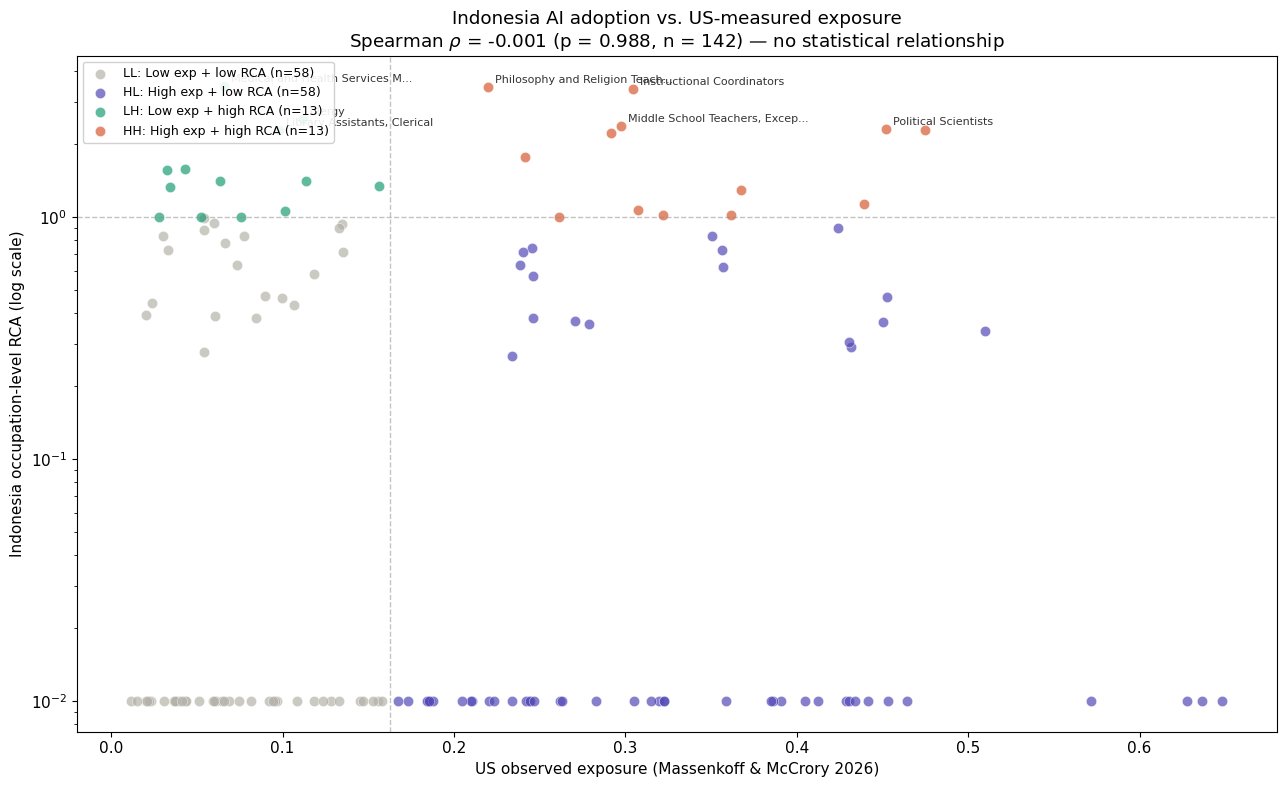

In [11]:
fig, ax = plt.subplots(figsize=(13, 8))

colors = {'HH': '#D85A30', 'HL': '#534AB7', 'LH': '#1D9E75', 'LL': '#B4B2A9'}
labels = {
    'HH': f'HH: High exp + high RCA (n={quadrant_counts.get("HH", 0)})',
    'HL': f'HL: High exp + low RCA (n={quadrant_counts.get("HL", 0)})',
    'LH': f'LH: Low exp + high RCA (n={quadrant_counts.get("LH", 0)})',
    'LL': f'LL: Low exp + low RCA (n={quadrant_counts.get("LL", 0)})',
}

# Plot points with small jitter on zero RCA so they don't all overlap on the axis
for q in ['LL', 'HL', 'LH', 'HH']:  # LL underneath, HH on top
    sub = both[both.quadrant == q]
    y_plot = sub.RCA.copy()
    # For log-scale, nudge true zeros so they render
    y_plot = y_plot.where(y_plot > 0, 0.01)
    ax.scatter(sub.observed_exposure, y_plot, s=55, alpha=0.7,
               color=colors[q], edgecolor='white', linewidth=0.4, label=labels[q])

# Annotate a few notable occupations in HH and LH
for _, r in both[both.quadrant == 'HH'].nlargest(4, 'RCA').iterrows():
    short = r.title if len(str(r.title)) < 32 else r.title[:29] + '...'
    ax.annotate(short, (r.observed_exposure, r.RCA), xytext=(5, 3),
                textcoords='offset points', fontsize=8, color='#333')
for _, r in both[both.quadrant == 'LH'].nlargest(3, 'RCA').iterrows():
    short = r.title if len(str(r.title)) < 32 else r.title[:29] + '...'
    ax.annotate(short, (r.observed_exposure, r.RCA), xytext=(5, 3),
                textcoords='offset points', fontsize=8, color='#333')

ax.axhline(1.0, color='#888', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(exp_median, color='#888', linestyle='--', alpha=0.5, linewidth=1)
ax.set_yscale('log')
ax.set_xlabel('US observed exposure (Massenkoff & McCrory 2026)')
ax.set_ylabel('Indonesia occupation-level RCA (log scale)')
ax.set_title(f'Indonesia AI adoption vs. US-measured exposure\n'
             f'Spearman $\\rho$ = {rho:+.3f} (p = {p_value:.3f}, n = {n}) — no statistical relationship')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scatter_rca_vs_exposure.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Results summary for the thesis

In [12]:
hh_n = quadrant_counts.get('HH', 0)
hl_n = quadrant_counts.get('HL', 0)
lh_n = quadrant_counts.get('LH', 0)
ll_n = quadrant_counts.get('LL', 0)

summary = f'''
DOES INDONESIA'S AI ADOPTION TRACK US-MEASURED EXPOSURE?
=========================================================

HEADLINE
  Spearman rho = {rho:+.4f}
  p-value      = {p_value:.4f}
  Sample size  = {n} occupations
  Decision:    {"REJECT H0" if p_value < 0.05 else "FAIL TO REJECT H0"} at alpha = 0.05
  Finding:     {"Relationship exists" if p_value < 0.05 else "No statistical relationship"}

DISTRIBUTIONAL JUSTIFICATION FOR SPEARMAN
  US exposure Shapiro-Wilk p:    {diag.iloc[0].shapiro_p:.2e}  (reject normality)
  Indonesia RCA Shapiro-Wilk p:  {diag.iloc[1].shapiro_p:.2e}  (reject normality)
  Either univariate failure is sufficient to reject bivariate normality;
  Spearman is appropriate (Hollander, Wolfe & Chicken 2014, Ch. 8).

QUADRANT DECOMPOSITION (explains the null)
  HH (high exp + high RCA):  {hh_n:3d} ({100*hh_n/n:.1f}%) — observable adjustment
  HL (high exp + low RCA):   {hl_n:3d} ({100*hl_n/n:.1f}%) — latent adoption gap
  LH (low exp + high RCA):   {lh_n:3d} ({100*lh_n/n:.1f}%) — distinctive Indonesian
  LL (low exp + low RCA):    {ll_n:3d} ({100*ll_n/n:.1f}%) — outside AI footprint

INTERPRETATION
  The near-zero Spearman coefficient is not an absence of pattern. It is
  the geometric result of two offsetting specializations: Indonesia over-
  adopts in occupations the US exposure metric marks low (LH quadrant)
  and under-adopts in occupations the US exposure metric marks high
  (HL quadrant). These cancel at the rank-correlation level while each
  is substantively informative on its own.

POLICY IMPLICATION
  US exposure estimates do not transfer to Indonesia. Policy frameworks
  derived from US labor market analysis - including retraining priorities
  based on displacement risk rankings - will systematically misallocate
  if applied directly to Indonesia. Acemoglu (2024) explicitly flagged
  this possibility; our result provides empirical support.

FILES
  outputs/distributional_diagnostic.csv
  outputs/quadrant_analysis.csv
  outputs/scatter_rca_vs_exposure.png
'''
print(summary)

with open(OUTPUT_DIR / 'thesis_results.txt', 'w') as f:
    f.write(summary)


DOES INDONESIA'S AI ADOPTION TRACK US-MEASURED EXPOSURE?

HEADLINE
  Spearman rho = -0.0013
  p-value      = 0.9879
  Sample size  = 142 occupations
  Decision:    FAIL TO REJECT H0 at alpha = 0.05
  Finding:     No statistical relationship

DISTRIBUTIONAL JUSTIFICATION FOR SPEARMAN
  US exposure Shapiro-Wilk p:    1.53e-07  (reject normality)
  Indonesia RCA Shapiro-Wilk p:  6.12e-16  (reject normality)
  Either univariate failure is sufficient to reject bivariate normality;
  Spearman is appropriate (Hollander, Wolfe & Chicken 2014, Ch. 8).

QUADRANT DECOMPOSITION (explains the null)
  HH (high exp + high RCA):   13 (9.2%) — observable adjustment
  HL (high exp + low RCA):    58 (40.8%) — latent adoption gap
  LH (low exp + high RCA):    13 (9.2%) — distinctive Indonesian
  LL (low exp + low RCA):     58 (40.8%) — outside AI footprint

INTERPRETATION
  The near-zero Spearman coefficient is not an absence of pattern. It is
  the geometric result of two offsetting specializations: Ind

## 9. The thesis sentence

Drop this directly into the abstract:

> *Using occupation-level Claude usage data for Indonesia and US-measured observed exposure, we find no rank-correlation between Indonesia's AI adoption intensity and the US exposure hierarchy (Spearman $\rho$ = [value from cell 5], p = [value from cell 5], n = [value from cell 5]). The near-zero coefficient reflects two offsetting specializations: Indonesia over-adopts in occupations with low US exposure (notably Educational Instruction) and under-adopts in occupations with high US exposure (notably Computer & Mathematical), producing zero aggregate correlation while revealing a structurally distinct adoption trajectory. Policy frameworks derived from US exposure analysis do not transfer directly to Indonesia.*

## Limitations to state in the paper

- Single-week snapshot (August 4–11, 2025); no time dynamics
- Claude is one AI platform; ChatGPT and other platforms may show different country-level patterns
- O\*NET task content is US-derived; assumes task content comparability across countries
- Tasks below Anthropic's privacy threshold are filtered out of the public release
- The RCA is descriptive, not causal; we do not identify drivers of adoption differences